# Tarea 3: Polars
**LEAD University** | Ciencia de Datos
Dataset: [100,000 Diabetes Clinical Dataset](https://www.kaggle.com/datasets/priyamchoksi/100000-diabetes-clinical-dataset) — Kaggle


In [6]:
# Instalar dependencias si es necesario
# Ejecutar en la terminal, no dentro del notebook activo:
# python -m pip install -r requirements.txt


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import time
import warnings
import os
import psutil

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_PATH = 'diabetes_dataset.csv'  # ajustar ruta si es necesario
RANDOM_STATE = 42

print(f"Polars v{pl.__version__} | Pandas v{pd.__version__}")
print(f"CPU cores: {os.cpu_count()} | RAM: {psutil.virtual_memory().total / 1e9:.1f} GB")

Polars v1.41.2 | Pandas v3.0.3
CPU cores: 12 | RAM: 17.0 GB
Polars v1.41.2 | Pandas v3.0.3
CPU cores: 12 | RAM: 17.0 GB


## Parte 1: Análisis Exploratorio (EDA) con Polars

### 1.1 Carga y descripción del dataset

In [3]:
df = pl.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head(5)

Shape: (100000, 16)


year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
i64,str,f64,str,i64,i64,i64,i64,i64,i64,i64,str,f64,f64,i64,i64
2020,"""Female""",32.0,"""Alabama""",0,0,0,0,1,0,0,"""never""",27.32,5.0,100,0
2015,"""Female""",29.0,"""Alabama""",0,1,0,0,0,0,0,"""never""",19.95,5.0,90,0
2015,"""Male""",18.0,"""Alabama""",0,0,0,0,1,0,0,"""never""",23.76,4.8,160,0
2015,"""Male""",41.0,"""Alabama""",0,0,1,0,0,0,0,"""never""",27.32,4.0,159,0
2016,"""Female""",52.0,"""Alabama""",1,0,0,0,0,0,0,"""never""",23.75,6.5,90,0


In [4]:
# Tipos de datos
df.schema

Schema([('year', Int64),
        ('gender', String),
        ('age', Float64),
        ('location', String),
        ('race:AfricanAmerican', Int64),
        ('race:Asian', Int64),
        ('race:Caucasian', Int64),
        ('race:Hispanic', Int64),
        ('race:Other', Int64),
        ('hypertension', Int64),
        ('heart_disease', Int64),
        ('smoking_history', String),
        ('bmi', Float64),
        ('hbA1c_level', Float64),
        ('blood_glucose_level', Int64),
        ('diabetes', Int64)])

**Variables del dataset:**
- `year`: año del registro
- `gender`: sexo del paciente
- `age`: edad
- `location`: estado de EE.UU.
- `race:*` (5 cols): indicadores one-hot de etnia
- `hypertension`, `heart_disease`: condiciones previas (binario)
- `smoking_history`: historial de tabaquismo
- `bmi`: índice de masa corporal
- `hbA1c_level`: nivel de hemoglobina glicosilada
- `blood_glucose_level`: glucosa en sangre
- `diabetes`: variable objetivo (0 = no diabético, 1 = diabético)

## 1.2 Estadisticas Descriptivas

In [5]:
df.describe()

statistic,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
str,f64,str,f64,str,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64
"""count""",100000.0,"""100000""",100000.0,"""100000""",100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,"""100000""",100000.0,100000.0,100000.0,100000.0
"""null_count""",0.0,"""0""",0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0
"""mean""",2018.36082,null,41.885856,null,0.20223,0.20015,0.19876,0.19888,0.19998,0.07485,0.03942,null,27.320767,5.527507,138.05806,0.085
"""std""",1.345239,null,22.51684,null,0.401665,0.400114,0.399069,0.39916,0.399987,0.26315,0.194593,null,6.636783,1.070672,40.708136,0.278883
"""min""",2015.0,"""Female""",0.08,"""Alabama""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""No Info""",10.01,3.5,80.0,0.0
"""25%""",2019.0,null,24.0,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,23.63,4.8,100.0,0.0
"""50%""",2019.0,null,43.0,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,27.32,5.8,140.0,0.0
"""75%""",2019.0,null,60.0,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,29.58,6.2,159.0,0.0
"""max""",2022.0,"""Other""",80.0,"""Wyoming""",1.0,1.0,1.0,1.0,1.0,1.0,1.0,"""not current""",95.69,9.0,300.0,1.0


## Analisis de valores faltantes

In [6]:
nulls = df.select(pl.all().is_null().sum()).transpose(include_header=True, header_name='columna', column_names=['nulos'])
nulls = nulls.filter(pl.col('nulos') > 0)
print("Columnas con valores nulos:")
print(nulls if nulls.height > 0 else "Ninguna — el dataset está limpio")

Columnas con valores nulos:
Ninguna — el dataset está limpio


### 1.4 Distribución de la variable objetivo

shape: (2, 2)
┌──────────┬───────┐
│ diabetes ┆ count │
│ ---      ┆ ---   │
│ i64      ┆ u32   │
╞══════════╪═══════╡
│ 0        ┆ 91500 │
│ 1        ┆ 8500  │
└──────────┴───────┘


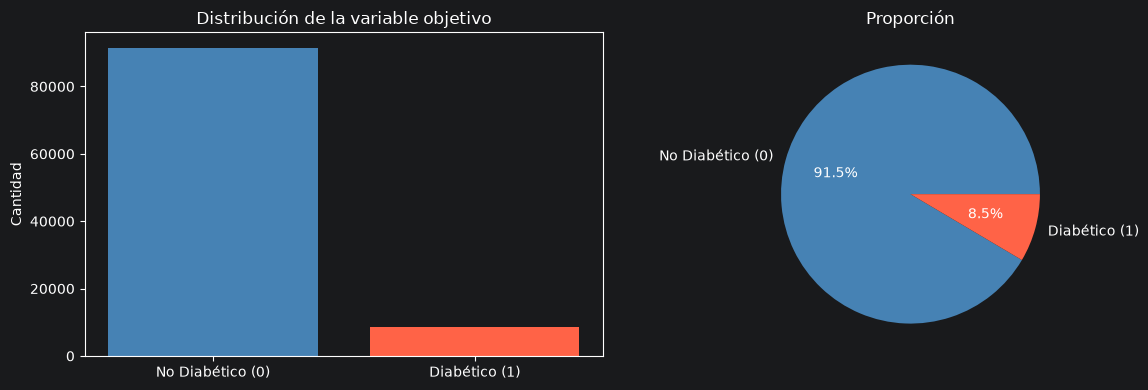

In [7]:
target_dist = df.group_by('diabetes').agg(pl.len().alias('count')).sort('diabetes')
print(target_dist)

counts = target_dist['count'].to_list()
labels = ['No Diabético (0)', 'Diabético (1)']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(labels, counts, color=['steelblue', 'tomato'])
axes[0].set_title('Distribución de la variable objetivo')
axes[0].set_ylabel('Cantidad')
axes[1].pie(counts, labels=labels, autopct='%1.1f%%', colors=['steelblue', 'tomato'])
axes[1].set_title('Proporción')
plt.tight_layout()
plt.show()

### 1.5 Distribución de variables numéricas


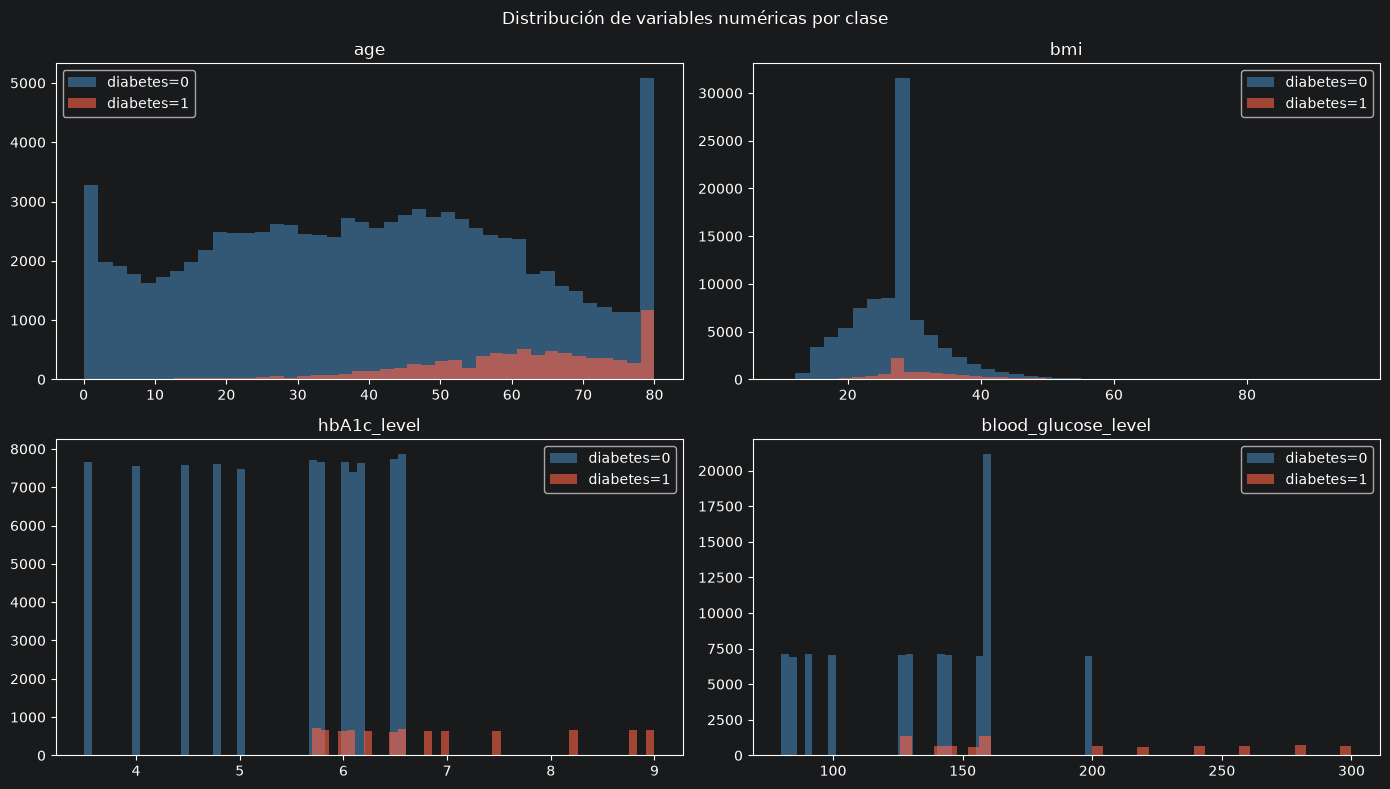

In [8]:
# Se usan arrays de numpy directamente desde Polars, sin necesidad de pyarrow
num_cols = ['age', 'bmi', 'hbA1c_level', 'blood_glucose_level']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flat, num_cols):
    for label, color in [(0, 'steelblue'), (1, 'tomato')]:
        vals = df.filter(pl.col('diabetes') == label)[col].to_numpy()
        ax.hist(vals, bins=40, alpha=0.6, color=color, label=f'diabetes={label}')
    ax.set_title(col)
    ax.legend()
plt.suptitle('Distribución de variables numéricas por clase')
plt.tight_layout()
plt.show()

### 1.6 Distribución de variables categóricas


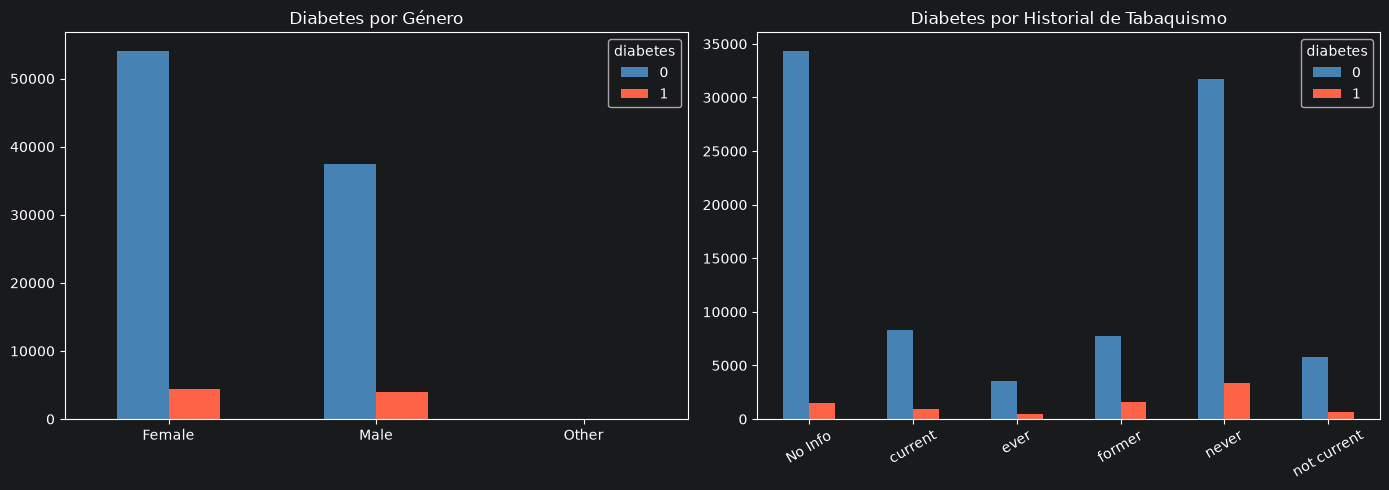

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Género — extraído con Polars, pivoteado con pandas sin pyarrow
gender_dist = (
    df.group_by(['gender', 'diabetes'])
    .agg(pl.len().alias('count'))
    .sort(['gender', 'diabetes'])
)
genders  = gender_dist['gender'].to_list()
diab_lbl = gender_dist['diabetes'].to_list()
counts_g = gender_dist['count'].to_list()
gd = pd.DataFrame({'gender': genders, 'diabetes': diab_lbl, 'count': counts_g})
gd.pivot(index='gender', columns='diabetes', values='count').fillna(0).plot(
    kind='bar', ax=axes[0], color=['steelblue', 'tomato']
)
axes[0].set_title('Diabetes por Género')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

# Tabaquismo
smoke_dist = (
    df.group_by(['smoking_history', 'diabetes'])
    .agg(pl.len().alias('count'))
    .sort(['smoking_history', 'diabetes'])
)
sd = pd.DataFrame({
    'smoking_history': smoke_dist['smoking_history'].to_list(),
    'diabetes': smoke_dist['diabetes'].to_list(),
    'count': smoke_dist['count'].to_list()
})
sd.pivot(index='smoking_history', columns='diabetes', values='count').fillna(0).plot(
    kind='bar', ax=axes[1], color=['steelblue', 'tomato']
)
axes[1].set_title('Diabetes por Historial de Tabaquismo')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 1.7 Análisis de correlaciones


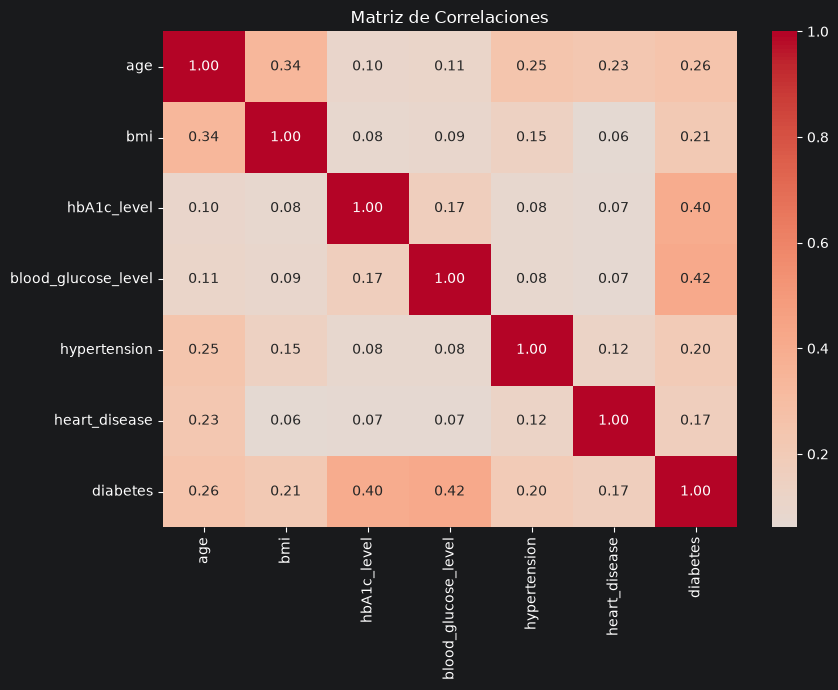

In [10]:
num_df = df.select(['age', 'bmi', 'hbA1c_level', 'blood_glucose_level',
                    'hypertension', 'heart_disease', 'diabetes'])

# Construir matriz de correlación con numpy, sin pyarrow
arr = np.column_stack([num_df[c].to_numpy() for c in num_df.columns])
corr_matrix = pd.DataFrame(np.corrcoef(arr.T), columns=num_df.columns, index=num_df.columns)

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de Correlaciones')
plt.tight_layout()
plt.show()

In [11]:
# Correlación con el target usando Polars nativo
corr_with_target = num_df.select([
    pl.corr(col, 'diabetes').alias(col)
    for col in ['age', 'bmi', 'hbA1c_level', 'blood_glucose_level', 'hypertension', 'heart_disease']
])
print("Correlación con diabetes:")
corr_with_target

Correlación con diabetes:


age,bmi,hbA1c_level,blood_glucose_level,hypertension,heart_disease
f64,f64,f64,f64,f64,f64
0.258008,0.214357,0.40066,0.419558,0.197823,0.171727


### 1.8 Análisis por grupo (group_by con Polars)

In [12]:
age_analysis = (
    df
    .with_columns(
        pl.when(pl.col('age') < 30).then(pl.lit('<30'))
        .when(pl.col('age') < 45).then(pl.lit('30-44'))
        .when(pl.col('age') < 60).then(pl.lit('45-59'))
        .otherwise(pl.lit('60+'))
        .alias('age_group')
    )
    .group_by('age_group')
    .agg([
        pl.len().alias('total'),
        pl.col('diabetes').mean().alias('diabetes_rate'),
        pl.col('bmi').mean().alias('avg_bmi'),
        pl.col('hbA1c_level').mean().alias('avg_hbA1c')
    ])
    .sort('age_group')
)
print(age_analysis)

shape: (4, 5)
┌───────────┬───────┬───────────────┬───────────┬───────────┐
│ age_group ┆ total ┆ diabetes_rate ┆ avg_bmi   ┆ avg_hbA1c │
│ ---       ┆ ---   ┆ ---           ┆ ---       ┆ ---       │
│ str       ┆ u32   ┆ f64           ┆ f64       ┆ f64       │
╞═══════════╪═══════╪═══════════════╪═══════════╪═══════════╡
│ 30-44     ┆ 19973 ┆ 0.041706      ┆ 28.988456 ┆ 5.462589  │
│ 45-59     ┆ 22537 ┆ 0.109198      ┆ 29.479025 ┆ 5.573621  │
│ 60+       ┆ 25055 ┆ 0.196847      ┆ 28.548637 ┆ 5.694089  │
│ <30       ┆ 32435 ┆ 0.008448      ┆ 23.845703 ┆ 5.406761  │
└───────────┴───────┴───────────────┴───────────┴───────────┘


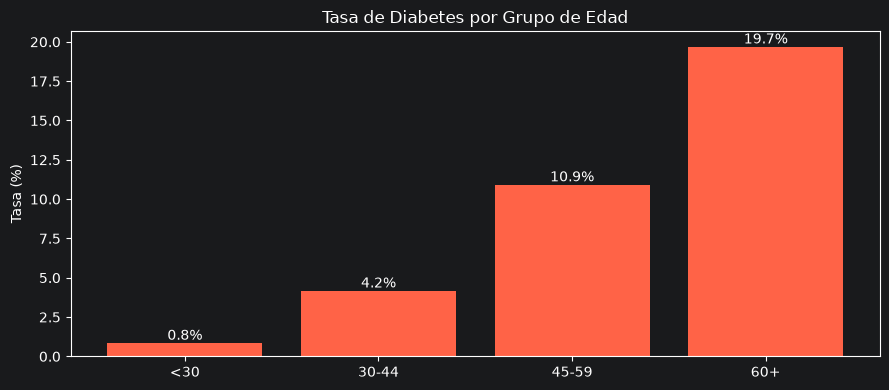

In [13]:
age_groups = age_analysis['age_group'].to_list()
diab_rates = age_analysis['diabetes_rate'].to_list()

# Ordenar manualmente
order = {'<30': 0, '30-44': 1, '45-59': 2, '60+': 3}
paired = sorted(zip(age_groups, diab_rates), key=lambda x: order.get(x[0], 99))
age_groups_s, diab_rates_s = zip(*paired)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(age_groups_s, [r * 100 for r in diab_rates_s], color='tomato')
ax.bar_label(bars, fmt='%.1f%%')
ax.set_title('Tasa de Diabetes por Grupo de Edad')
ax.set_ylabel('Tasa (%)')
plt.tight_layout()
plt.show()

## Parte 2: Ingeniería de Características con Polars
Pipeline con filtrado, transformación, manejo de nulos, nuevas características, join y group_by.

In [14]:
# Tabla auxiliar para el join: tasa de diabetes por estado
location_stats = (
    df
    .group_by('location')
    .agg(pl.col('diabetes').mean().alias('location_diabetes_rate'))
)
location_stats.head(5)

location,location_diabetes_rate
str,f64
"""South Carolina""",0.08002
"""Utah""",0.0883
"""Nevada""",0.085096
"""New Jersey""",0.08002
"""Connecticut""",0.088452


In [15]:
def polars_feature_pipeline(data: pl.DataFrame, loc_stats: pl.DataFrame) -> pl.DataFrame:
    return (
        data
        # Filtrado
        .filter(pl.col('gender').is_in(['Male', 'Female']))
        # Manejo de nulos
        .with_columns([
            pl.col('bmi').fill_null(pl.col('bmi').mean()),
            pl.col('hbA1c_level').fill_null(pl.col('hbA1c_level').mean()),
            pl.col('blood_glucose_level').fill_null(pl.col('blood_glucose_level').mean()),
        ])
        # Encoding categórico
        .with_columns([
            pl.when(pl.col('gender') == 'Male').then(1).otherwise(0).alias('gender_enc'),
            pl.col('smoking_history').replace(
                {'never': 0, 'No Info': 0, 'not current': 1, 'former': 2, 'ever': 2, 'current': 3}
            ).cast(pl.Int32).alias('smoking_enc'),
        ])
        # Nuevas características
        .with_columns([
            (pl.col('bmi') * pl.col('hbA1c_level') / 10).alias('metabolic_risk'),
            pl.when(pl.col('bmi') < 18.5).then(pl.lit('underweight'))
              .when(pl.col('bmi') < 25).then(pl.lit('normal'))
              .when(pl.col('bmi') < 30).then(pl.lit('overweight'))
              .otherwise(pl.lit('obese'))
              .alias('bmi_category'),
            (pl.col('blood_glucose_level') > 140).cast(pl.Int32).alias('high_glucose'),
            (pl.col('hbA1c_level') >= 6.5).cast(pl.Int32).alias('hbA1c_diabetic_range'),
            (pl.col('hypertension') + pl.col('heart_disease')).alias('comorbidity_score'),
            pl.when(pl.col('age') < 30).then(0)
              .when(pl.col('age') < 45).then(1)
              .when(pl.col('age') < 60).then(2)
              .otherwise(3)
              .alias('age_group_enc'),
        ])
        .with_columns(
            pl.col('bmi_category').replace(
                {'underweight': 0, 'normal': 1, 'overweight': 2, 'obese': 3}
            ).cast(pl.Int32).alias('bmi_cat_enc')
        )
        # Join con estadísticas por estado
        .join(loc_stats, on='location', how='left')
    )

df_feat = polars_feature_pipeline(df, location_stats)
print(f"Shape después del pipeline: {df_feat.shape}")
df_feat.head(3)

Shape después del pipeline: (99982, 26)


year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes,gender_enc,smoking_enc,metabolic_risk,bmi_category,high_glucose,hbA1c_diabetic_range,comorbidity_score,age_group_enc,bmi_cat_enc,location_diabetes_rate
i64,str,f64,str,i64,i64,i64,i64,i64,i64,i64,str,f64,f64,f64,i64,i32,i32,f64,str,i32,i32,i64,i32,i32,f64
2020,"""Female""",32.0,"""Alabama""",0,0,0,0,1,0,0,"""never""",27.32,5.0,100.0,0,0,0,13.66,"""overweight""",0,0,0,1,2,0.085953
2015,"""Female""",29.0,"""Alabama""",0,1,0,0,0,0,0,"""never""",19.95,5.0,90.0,0,0,0,9.975,"""normal""",0,0,0,0,1,0.085953
2015,"""Male""",18.0,"""Alabama""",0,0,0,0,1,0,0,"""never""",23.76,4.8,160.0,0,1,0,11.4048,"""normal""",1,0,0,0,1,0.085953


In [16]:
# Agregación group_by: resumen por categoría de BMI
bmi_summary = (
    df_feat
    .group_by('bmi_category')
    .agg([
        pl.len().alias('n'),
        pl.col('diabetes').mean().alias('diabetes_rate'),
        pl.col('metabolic_risk').mean().alias('avg_metabolic_risk'),
        pl.col('hbA1c_level').mean().alias('avg_hbA1c')
    ])
    .sort('diabetes_rate', descending=True)
)
print(bmi_summary)

shape: (4, 5)
┌──────────────┬───────┬───────────────┬────────────────────┬───────────┐
│ bmi_category ┆ n     ┆ diabetes_rate ┆ avg_metabolic_risk ┆ avg_hbA1c │
│ ---          ┆ ---   ┆ ---           ┆ ---                ┆ ---       │
│ str          ┆ u32   ┆ f64           ┆ f64                ┆ f64       │
╞══════════════╪═══════╪═══════════════╪════════════════════╪═══════════╡
│ obese        ┆ 23530 ┆ 0.179898      ┆ 20.53555           ┆ 5.670472  │
│ overweight   ┆ 45744 ┆ 0.073015      ┆ 15.071981          ┆ 5.510119  │
│ normal       ┆ 22216 ┆ 0.038846      ┆ 12.067649          ┆ 5.455226  │
│ underweight  ┆ 8492  ┆ 0.007537      ┆ 8.836522           ┆ 5.41439   │
└──────────────┴───────┴───────────────┴────────────────────┴───────────┘


In [17]:
FEATURE_COLS = [
    'age', 'gender_enc', 'smoking_enc', 'bmi', 'hbA1c_level', 'blood_glucose_level',
    'hypertension', 'heart_disease', 'metabolic_risk', 'high_glucose',
    'hbA1c_diabetic_range', 'comorbidity_score', 'age_group_enc', 'bmi_cat_enc',
    'location_diabetes_rate',
    'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other'
]
TARGET_COL = 'diabetes'

df_ml = df_feat.select(FEATURE_COLS + [TARGET_COL]).drop_nulls()
print(f"Dataset para ML: {df_ml.shape}")

Dataset para ML: (99982, 21)


## Parte 3: Machine Learning

In [18]:
X = np.column_stack([df_ml[c].to_numpy() for c in FEATURE_COLS])
y = df_ml[TARGET_COL].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Positivos — train: {y_train.mean():.3f} | test: {y_test.mean():.3f}")

Train: (79985, 20) | Test: (19997, 20)
Positivos — train: 0.085 | test: 0.085


In [19]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, scale=False):
    Xtr = X_train_sc if scale else X_tr
    Xte = X_test_sc  if scale else X_te
    t0 = time.time()
    model.fit(Xtr, y_tr)
    train_time = time.time() - t0
    y_pred  = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1] if hasattr(model, 'predict_proba') else y_pred
    return {
        'Modelo': name,
        'Accuracy': accuracy_score(y_te, y_pred),
        'F1': f1_score(y_te, y_pred),
        'AUC-ROC': roc_auc_score(y_te, y_proba),
        'Tiempo (s)': train_time
    }, model, y_pred

### 3.1 Regresión Logística


In [20]:
lr_metrics, lr_fitted, lr_pred = evaluate_model(
    'Logistic Regression',
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    X_train, y_train, X_test, y_test, scale=True
)
print(lr_metrics)

{'Modelo': 'Logistic Regression', 'Accuracy': 0.964444666700005, 'F1': 0.755586112066002, 'AUC-ROC': 0.9625702702789593, 'Tiempo (s)': 0.14622020721435547}


### 3.2 Random Forest


In [21]:
rf_metrics, rf_fitted, rf_pred = evaluate_model(
    'Random Forest',
    RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE),
    X_train, y_train, X_test, y_test
)
print(rf_metrics)

{'Modelo': 'Random Forest', 'Accuracy': 0.9718957843676551, 'F1': 0.8045897079276774, 'AUC-ROC': 0.968372475076274, 'Tiempo (s)': 3.038902759552002}


### 3.3 Gradient Boosting (XGBoost)


In [22]:
xgb_metrics, xgb_fitted, xgb_pred = evaluate_model(
    'XGBoost',
    xgb.XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1
    ),
    X_train, y_train, X_test, y_test
)
print(xgb_metrics)

{'Modelo': 'XGBoost', 'Accuracy': 0.9726458968845327, 'F1': 0.8100034734282737, 'AUC-ROC': 0.9783741789878765, 'Tiempo (s)': 0.8644587993621826}


### 3.4 LightGBM

In [23]:
lgbm_metrics, lgbm_fitted, lgbm_pred = evaluate_model(
    'LightGBM',
    lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=63,
                       random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    X_train, y_train, X_test, y_test
)
print(lgbm_metrics)

{'Modelo': 'LightGBM', 'Accuracy': 0.9719957993699054, 'F1': 0.8066298342541437, 'AUC-ROC': 0.9772443891476906, 'Tiempo (s)': 1.4850127696990967}


### 3.5 Comparación de modelos

In [24]:
results_df = pd.DataFrame([lr_metrics, rf_metrics, xgb_metrics, lgbm_metrics])
results_df = results_df.set_index('Modelo').sort_values('AUC-ROC', ascending=False)
print(results_df.round(4))

                     Accuracy      F1  AUC-ROC  Tiempo (s)
Modelo                                                    
XGBoost                0.9726  0.8100   0.9784      0.8645
LightGBM               0.9720  0.8066   0.9772      1.4850
Random Forest          0.9719  0.8046   0.9684      3.0389
Logistic Regression    0.9644  0.7556   0.9626      0.1462


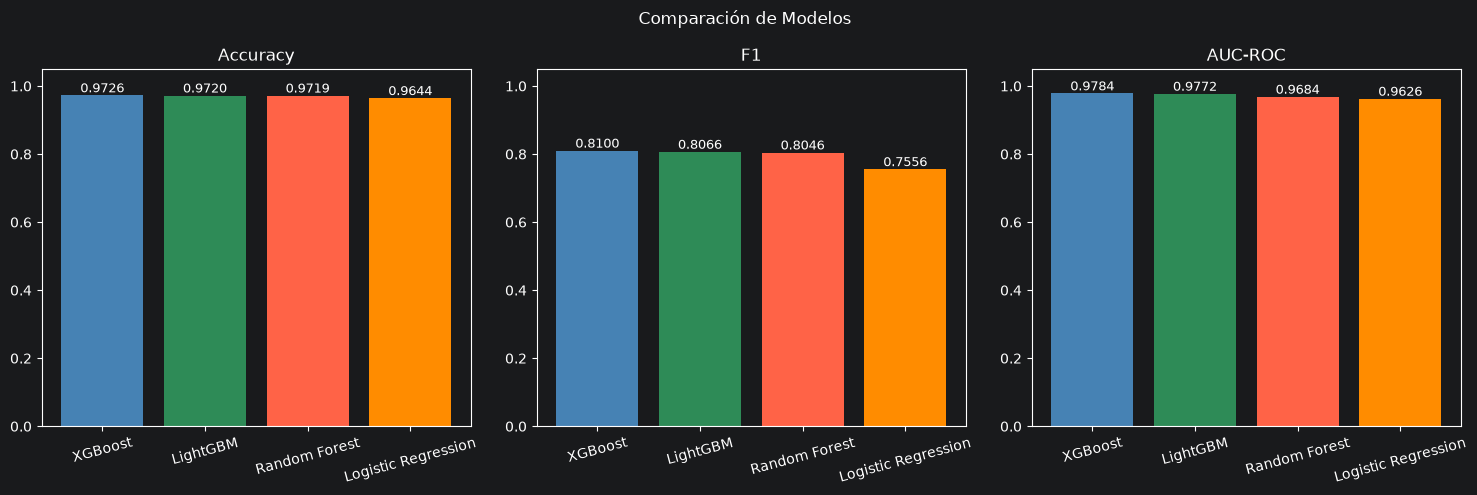

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['steelblue', 'seagreen', 'tomato', 'darkorange']
for ax, metric in zip(axes, ['Accuracy', 'F1', 'AUC-ROC']):
    bars = ax.bar(results_df.index, results_df[metric], color=colors)
    ax.bar_label(bars, fmt='%.4f', fontsize=9)
    ax.set_title(metric)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=15)
plt.suptitle('Comparación de Modelos')
plt.tight_layout()
plt.show()

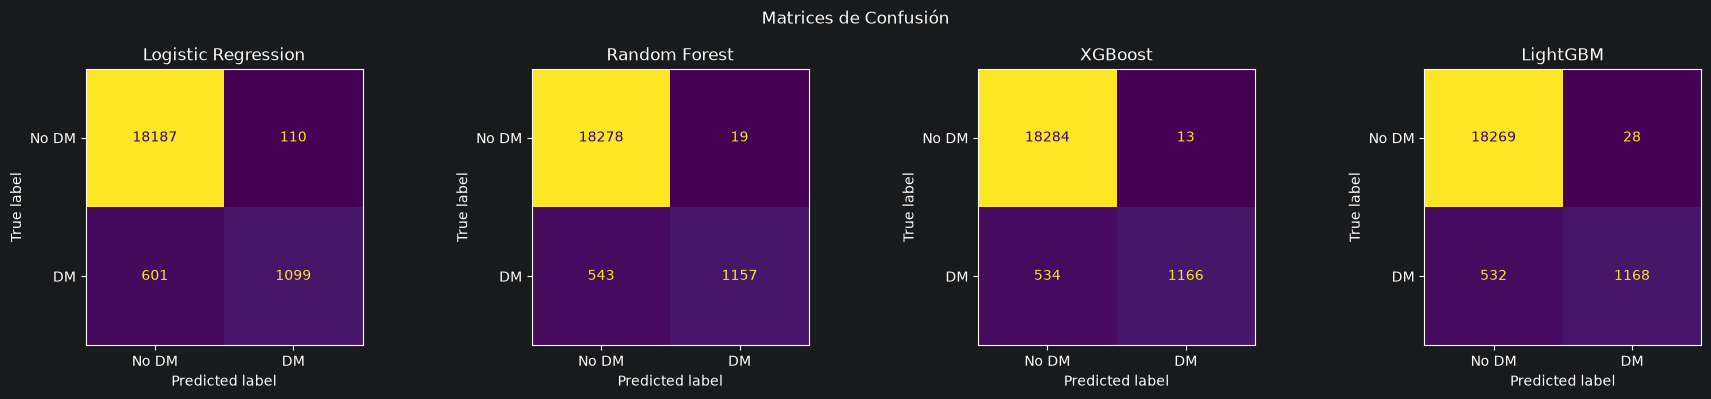

In [26]:
# Matrices de confusión
models_preds = [
    ('Logistic Regression', lr_pred),
    ('Random Forest', rf_pred),
    ('XGBoost', xgb_pred),
    ('LightGBM', lgbm_pred)
]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, pred) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No DM', 'DM']).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.suptitle('Matrices de Confusión')
plt.tight_layout()
plt.show()

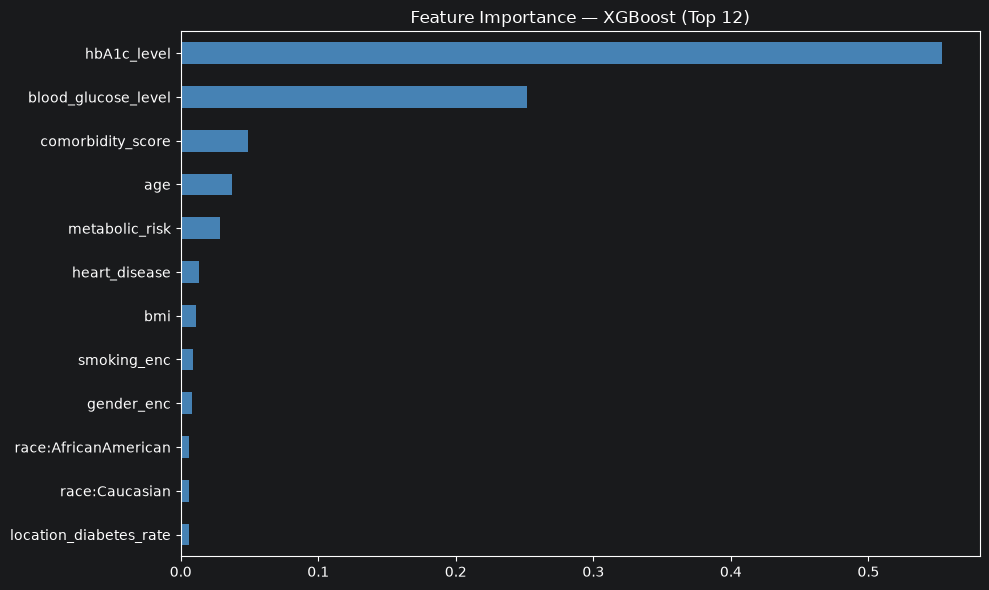

In [27]:
# Feature importance — XGBoost
fi = pd.Series(xgb_fitted.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True).tail(12)
fi.plot(kind='barh', figsize=(10, 6), color='steelblue')
plt.title('Feature Importance — XGBoost (Top 12)')
plt.tight_layout()
plt.show()

## Parte 4: Benchmark Polars vs Pandas

In [28]:
ram_gb  = psutil.virtual_memory().total / 1e9
file_mb = os.path.getsize(DATA_PATH) / 1e6
print(f"CPU cores: {os.cpu_count()} | RAM: {ram_gb:.1f} GB | Dataset: {file_mb:.1f} MB")

CPU cores: 12 | RAM: 17.0 GB | Dataset: 6.1 MB


In [29]:
REPS = 3

def time_it(fn, reps=REPS):
    times = []
    for _ in range(reps):
        t0 = time.time()
        result = fn()
        times.append(time.time() - t0)
    return np.mean(times), result

### 4.1 Lectura


In [30]:
t_polars_read, _ = time_it(lambda: pl.read_csv(DATA_PATH))
t_pandas_read, _ = time_it(lambda: pd.read_csv(DATA_PATH))
print(f"Lectura — Polars: {t_polars_read:.4f}s | Pandas: {t_pandas_read:.4f}s | Speedup: {t_pandas_read/t_polars_read:.2f}x")

Lectura — Polars: 0.0111s | Pandas: 0.3129s | Speedup: 28.08x


In [31]:
df_bench_pl = pl.read_csv(DATA_PATH)
df_bench_pd = pd.read_csv(DATA_PATH)

### 4.2 Filtrado

In [32]:
t_polars_filter, _ = time_it(
    lambda: df_bench_pl.filter((pl.col('age') > 40) & (pl.col('bmi') > 25))
)
t_pandas_filter, _ = time_it(
    lambda: df_bench_pd[(df_bench_pd['age'] > 40) & (df_bench_pd['bmi'] > 25)]
)
print(f"Filtrado — Polars: {t_polars_filter:.4f}s | Pandas: {t_pandas_filter:.4f}s | Speedup: {t_pandas_filter/t_polars_filter:.2f}x")

Filtrado — Polars: 0.0055s | Pandas: 0.0052s | Speedup: 0.96x


### 4.3 Agregación

In [33]:
t_polars_agg, _ = time_it(
    lambda: df_bench_pl.group_by('smoking_history').agg([
        pl.col('diabetes').mean(), pl.col('bmi').mean(), pl.col('hbA1c_level').mean()
    ])
)
t_pandas_agg, _ = time_it(
    lambda: df_bench_pd.groupby('smoking_history')[['diabetes', 'bmi', 'hbA1c_level']].mean()
)
print(f"Agregación — Polars: {t_polars_agg:.4f}s | Pandas: {t_pandas_agg:.4f}s | Speedup: {t_pandas_agg/t_polars_agg:.2f}x")

Agregación — Polars: 0.0028s | Pandas: 0.0124s | Speedup: 4.35x


### 4.4 Join

In [34]:
loc_stats_pd = df_bench_pd.groupby('location')['diabetes'].mean().reset_index()
loc_stats_pd.columns = ['location', 'location_diabetes_rate']

t_polars_join, _ = time_it(
    lambda: df_bench_pl.join(location_stats, on='location', how='left')
)
t_pandas_join, _ = time_it(
    lambda: df_bench_pd.merge(loc_stats_pd, on='location', how='left')
)
print(f"Join — Polars: {t_polars_join:.4f}s | Pandas: {t_pandas_join:.4f}s | Speedup: {t_pandas_join/t_polars_join:.2f}x")

Join — Polars: 0.0025s | Pandas: 0.0059s | Speedup: 2.38x


### 4.5 Feature Engineering completo

In [35]:
def pandas_feature_pipeline(data: pd.DataFrame, loc_stats: pd.DataFrame) -> pd.DataFrame:
    df_p = data[data['gender'].isin(['Male', 'Female'])].copy()
    for col in ['bmi', 'hbA1c_level', 'blood_glucose_level']:
        df_p[col] = df_p[col].fillna(df_p[col].mean())
    df_p['gender_enc'] = (df_p['gender'] == 'Male').astype(int)
    smoke_map = {'never': 0, 'No Info': 0, 'not current': 1, 'former': 2, 'ever': 2, 'current': 3}
    df_p['smoking_enc'] = df_p['smoking_history'].map(smoke_map).fillna(0).astype(int)
    df_p['metabolic_risk'] = df_p['bmi'] * df_p['hbA1c_level'] / 10
    df_p['bmi_category'] = pd.cut(df_p['bmi'], bins=[0, 18.5, 25, 30, 100],
                                   labels=['underweight', 'normal', 'overweight', 'obese'])
    df_p['high_glucose'] = (df_p['blood_glucose_level'] > 140).astype(int)
    df_p['hbA1c_diabetic_range'] = (df_p['hbA1c_level'] >= 6.5).astype(int)
    df_p['comorbidity_score'] = df_p['hypertension'] + df_p['heart_disease']
    df_p['age_group_enc'] = pd.cut(df_p['age'], bins=[0, 30, 45, 60, 200],
                                    labels=[0, 1, 2, 3]).astype(int)
    df_p['bmi_cat_enc'] = df_p['bmi_category'].map({'underweight': 0, 'normal': 1, 'overweight': 2, 'obese': 3})
    return df_p.merge(loc_stats, on='location', how='left')

t_polars_fe, _ = time_it(lambda: polars_feature_pipeline(df_bench_pl, location_stats))
t_pandas_fe, _ = time_it(lambda: pandas_feature_pipeline(df_bench_pd, loc_stats_pd))
print(f"Feature Engineering — Polars: {t_polars_fe:.4f}s | Pandas: {t_pandas_fe:.4f}s | Speedup: {t_pandas_fe/t_polars_fe:.2f}x")

Feature Engineering — Polars: 0.0276s | Pandas: 0.0446s | Speedup: 1.62x


### 4.6 Resumen del benchmark

In [36]:
benchmark = pd.DataFrame({
    'Operación':  ['Lectura CSV', 'Filtrado', 'Agregación', 'Join', 'Feature Engineering'],
    'Polars (s)': [t_polars_read, t_polars_filter, t_polars_agg, t_polars_join, t_polars_fe],
    'Pandas (s)': [t_pandas_read, t_pandas_filter, t_pandas_agg, t_pandas_join, t_pandas_fe],
})
benchmark['Speedup'] = benchmark['Pandas (s)'] / benchmark['Polars (s)']
benchmark = benchmark.set_index('Operación')
print(benchmark.round(4))

                     Polars (s)  Pandas (s)  Speedup
Operación                                           
Lectura CSV              0.0111      0.3129  28.0787
Filtrado                 0.0055      0.0052   0.9560
Agregación               0.0028      0.0124   4.3539
Join                     0.0025      0.0059   2.3823
Feature Engineering      0.0276      0.0446   1.6152


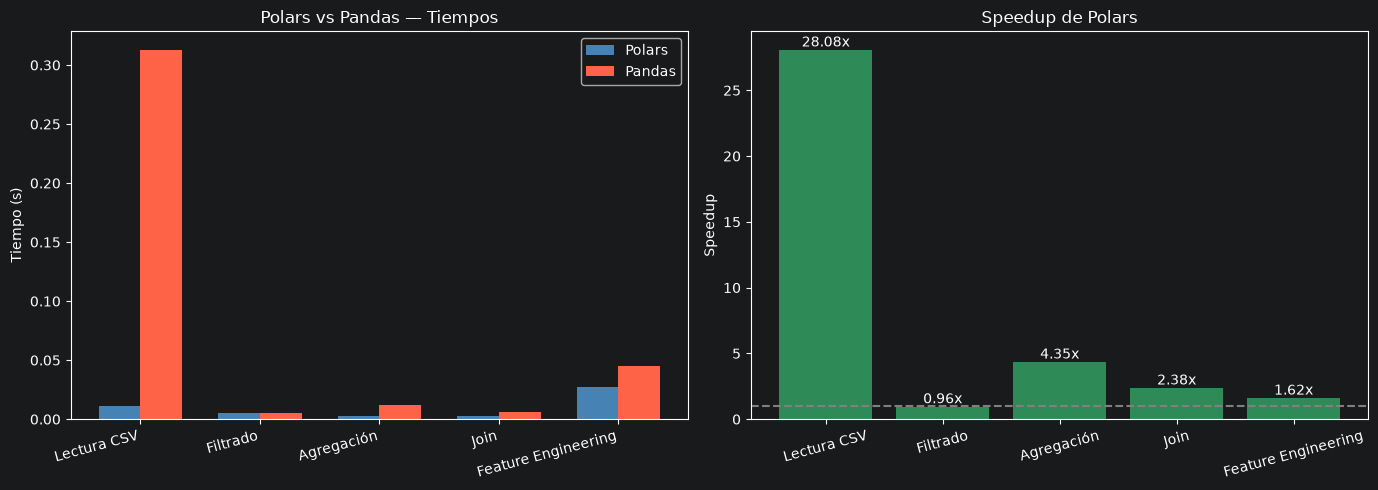

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(benchmark))
w = 0.35
axes[0].bar(x - w/2, benchmark['Polars (s)'], w, label='Polars', color='steelblue')
axes[0].bar(x + w/2, benchmark['Pandas (s)'], w, label='Pandas', color='tomato')
axes[0].set_xticks(x)
axes[0].set_xticklabels(benchmark.index, rotation=15, ha='right')
axes[0].set_ylabel('Tiempo (s)')
axes[0].set_title('Polars vs Pandas — Tiempos')
axes[0].legend()

bars = axes[1].bar(benchmark.index, benchmark['Speedup'], color='seagreen')
axes[1].bar_label(bars, fmt='%.2fx')
axes[1].axhline(1, color='gray', linestyle='--')
axes[1].set_ylabel('Speedup')
axes[1].set_title('Speedup de Polars')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

## Parte 5: Experimentos

### 5.1 Escalabilidad con tamaño de datos

In [38]:
fractions = [0.25, 0.50, 0.75, 1.00]
scalability_results = []

for frac in fractions:
    n = int(len(df_bench_pd) * frac)
    pd_sub = df_bench_pd.iloc[:n].copy()
    pl_sub = df_bench_pl.head(n)
    t_pd, _ = time_it(lambda: pandas_feature_pipeline(pd_sub, loc_stats_pd))
    t_pl, _ = time_it(lambda: polars_feature_pipeline(pl_sub, location_stats))
    scalability_results.append({
        'Fracción': f'{int(frac*100)}%',
        'N registros': n,
        'Pandas (s)': t_pd,
        'Polars (s)': t_pl,
        'Speedup': t_pd / t_pl
    })
    print(f"{int(frac*100)}% ({n:,}) — Pandas: {t_pd:.3f}s | Polars: {t_pl:.3f}s | Speedup: {t_pd/t_pl:.2f}x")

scale_df = pd.DataFrame(scalability_results)
print()
print(scale_df.round(4).to_string(index=False))

25% (25,000) — Pandas: 0.016s | Polars: 0.011s | Speedup: 1.48x
50% (50,000) — Pandas: 0.023s | Polars: 0.014s | Speedup: 1.68x
75% (75,000) — Pandas: 0.029s | Polars: 0.022s | Speedup: 1.30x
100% (100,000) — Pandas: 0.035s | Polars: 0.030s | Speedup: 1.16x

Fracción  N registros  Pandas (s)  Polars (s)  Speedup
     25%        25000      0.0162      0.0109   1.4833
     50%        50000      0.0233      0.0139   1.6780
     75%        75000      0.0289      0.0223   1.2997
    100%       100000      0.0351      0.0302   1.1637


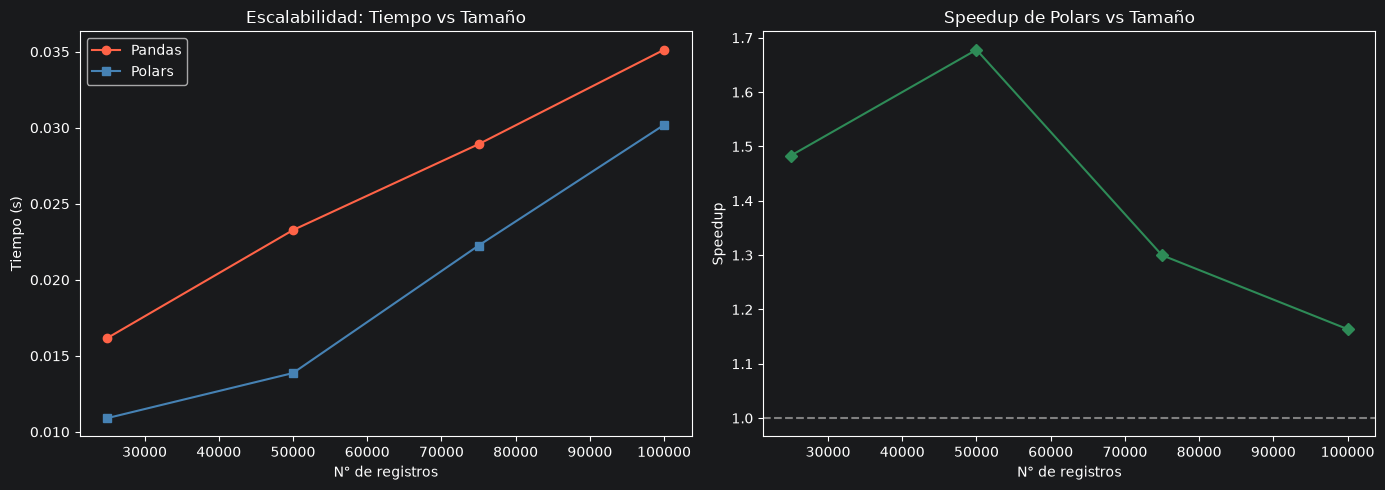

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(scale_df['N registros'], scale_df['Pandas (s)'], 'o-', color='tomato', label='Pandas')
axes[0].plot(scale_df['N registros'], scale_df['Polars (s)'], 's-', color='steelblue', label='Polars')
axes[0].set_xlabel('N° de registros')
axes[0].set_ylabel('Tiempo (s)')
axes[0].set_title('Escalabilidad: Tiempo vs Tamaño')
axes[0].legend()

axes[1].plot(scale_df['N registros'], scale_df['Speedup'], 'D-', color='seagreen')
axes[1].axhline(1, color='gray', linestyle='--')
axes[1].set_xlabel('N° de registros')
axes[1].set_ylabel('Speedup')
axes[1].set_title('Speedup de Polars vs Tamaño')
plt.tight_layout()
plt.show()

### 5.2 Lazy Execution: read_csv vs scan_csv

In [40]:
def eager_pipeline():
    return (
        pl.read_csv(DATA_PATH)
        .filter((pl.col('age') > 40) & (pl.col('bmi') > 25))
        .group_by('smoking_history')
        .agg(pl.col('diabetes').mean())
    )

def lazy_pipeline():
    return (
        pl.scan_csv(DATA_PATH)
        .filter((pl.col('age') > 40) & (pl.col('bmi') > 25))
        .group_by('smoking_history')
        .agg(pl.col('diabetes').mean())
        .collect()
    )

t_eager, _ = time_it(eager_pipeline)
t_lazy,  _ = time_it(lazy_pipeline)
print(f"Eager (read_csv):         {t_eager:.4f}s")
print(f"Lazy  (scan_csv+collect): {t_lazy:.4f}s")
print(f"Lazy es {((t_eager - t_lazy)/t_eager)*100:.1f}% más rápido")

Eager (read_csv):         0.0175s
Lazy  (scan_csv+collect): 0.0127s
Lazy es 27.4% más rápido


In [41]:
# Plan de ejecución optimizado por Polars
print(
    pl.scan_csv(DATA_PATH)
    .filter((pl.col('age') > 40) & (pl.col('bmi') > 25))
    .group_by('smoking_history')
    .agg(pl.col('diabetes').mean())
    .explain()
)

AGGREGATE[maintain_order: false]
  [col("diabetes").mean()] BY [col("smoking_history")]
  FROM
  simple π 2/2 ["smoking_history", "diabetes"]
    Csv SCAN [diabetes_dataset.csv]
    PROJECT 4/16 COLUMNS
    SELECTION: [([(col("age")) > (40.0)]) & ([(col("bmi")) > (25.0)])]
    ESTIMATED ROWS: 105886


In [42]:
import tracemalloc

tracemalloc.start()
_ = eager_pipeline()
_, peak_eager = tracemalloc.get_traced_memory()
tracemalloc.stop()

tracemalloc.start()
_ = lazy_pipeline()
_, peak_lazy = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"Memoria pico Eager: {peak_eager / 1e6:.2f} MB")
print(f"Memoria pico Lazy:  {peak_lazy / 1e6:.2f} MB")

Memoria pico Eager: 0.02 MB
Memoria pico Lazy:  0.02 MB


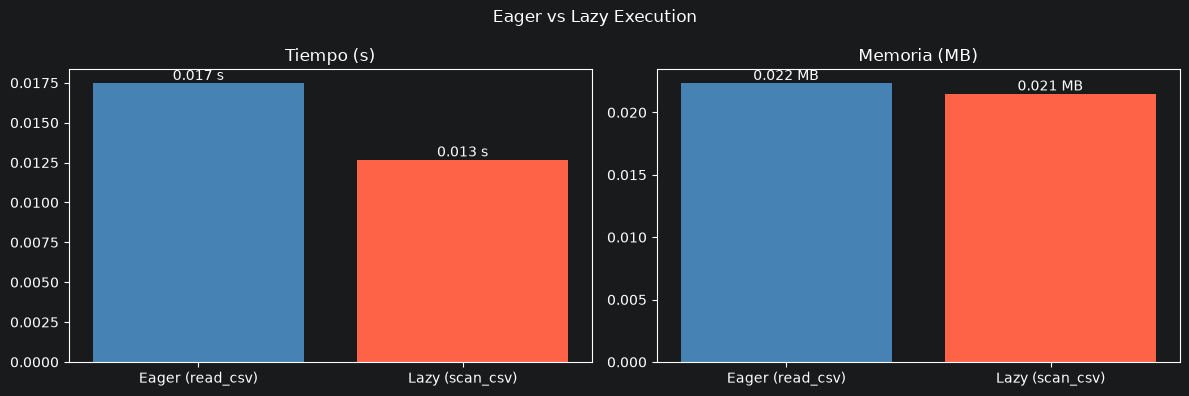

In [43]:
lazy_comparison = pd.DataFrame({
    'Modo':         ['Eager (read_csv)', 'Lazy (scan_csv)'],
    'Tiempo (s)':   [t_eager, t_lazy],
    'Memoria (MB)': [peak_eager / 1e6, peak_lazy / 1e6]
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['steelblue', 'tomato']
for ax, col, unit in zip(axes, ['Tiempo (s)', 'Memoria (MB)'], ['s', 'MB']):
    bars = ax.bar(lazy_comparison['Modo'], lazy_comparison[col], color=colors)
    ax.bar_label(bars, fmt=f'%.3f {unit}')
    ax.set_title(col)
plt.suptitle('Eager vs Lazy Execution')
plt.tight_layout()
plt.show()



## Parte 6: Trabajo Opcional — Dask


In [47]:
import dask
dask.config.set({"dataframe.convert-string": False})
import dask.dataframe as dd

In [48]:
import dask.dataframe as dd

# Dask infiere dtypes del primer chunk; se especifican para evitar conflictos entre chunks
DASK_DTYPES = {'age': 'float64', 'bmi': 'float64', 'hbA1c_level': 'float64',
               'blood_glucose_level': 'float64', 'year': 'int64'}

t_dask_read, _ = time_it(lambda: dd.read_csv(DATA_PATH, dtype=DASK_DTYPES).compute())
print(f"Lectura — Dask: {t_dask_read:.4f}s | Pandas: {t_pandas_read:.4f}s | Polars: {t_polars_read:.4f}s")

Lectura — Dask: 0.6139s | Pandas: 0.3129s | Polars: 0.0111s


In [49]:
ddf = dd.read_csv(DATA_PATH, dtype=DASK_DTYPES)

t_dask_filter, _ = time_it(lambda: ddf[(ddf['age'] > 40) & (ddf['bmi'] > 25)].compute())
t_dask_agg, _    = time_it(
    lambda: ddf.groupby('smoking_history')[['diabetes', 'bmi', 'hbA1c_level']].mean().compute()
)
print(f"Filtrado   — Dask: {t_dask_filter:.4f}s")
print(f"Agregación — Dask: {t_dask_agg:.4f}s")

Filtrado   — Dask: 0.1760s
Agregación — Dask: 0.3976s


In [50]:
triple_bench = pd.DataFrame({
    'Operación':  ['Lectura CSV', 'Filtrado', 'Agregación'],
    'Polars (s)': [t_polars_read, t_polars_filter, t_polars_agg],
    'Pandas (s)': [t_pandas_read, t_pandas_filter, t_pandas_agg],
    'Dask (s)':   [t_dask_read,   t_dask_filter,   t_dask_agg],
}).set_index('Operación')
print(triple_bench.round(4))

             Polars (s)  Pandas (s)  Dask (s)
Operación                                    
Lectura CSV      0.0111      0.3129    0.6139
Filtrado         0.0055      0.0052    0.1760
Agregación       0.0028      0.0124    0.3976


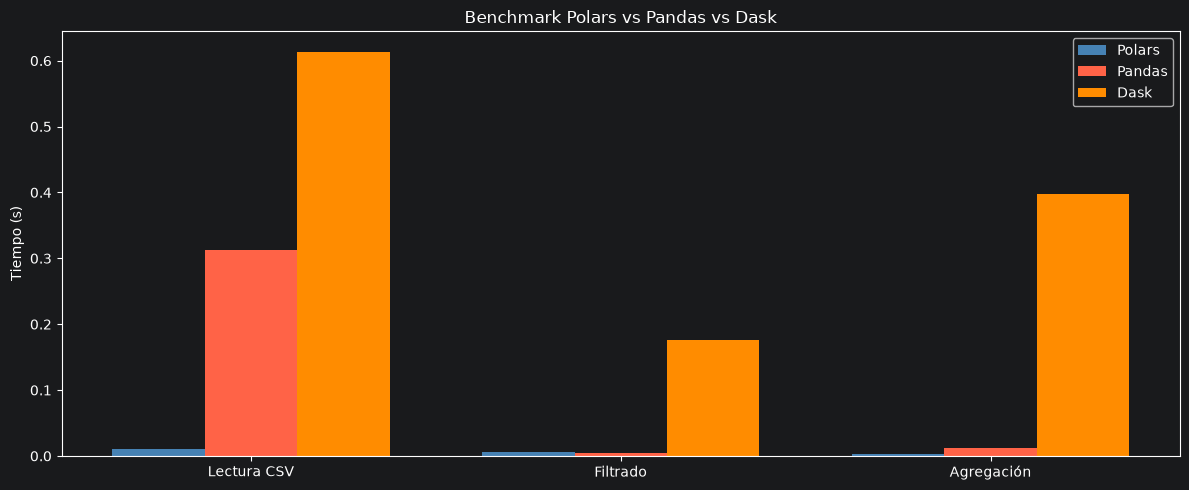

In [51]:
x = np.arange(len(triple_bench))
w = 0.25
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w, triple_bench['Polars (s)'], w, label='Polars', color='steelblue')
ax.bar(x,     triple_bench['Pandas (s)'], w, label='Pandas', color='tomato')
ax.bar(x + w, triple_bench['Dask (s)'],   w, label='Dask',   color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(triple_bench.index)
ax.set_ylabel('Tiempo (s)')
ax.set_title('Benchmark Polars vs Pandas vs Dask')
ax.legend()
plt.tight_layout()
plt.show()

## Resultados Esperados (Punto 9)

### Descripción del dataset

El dataset **100,000 Diabetes Clinical Dataset** (Kaggle) contiene registros clínicos sintéticos con información demográfica, historial médico y marcadores biológicos. Tiene **100,000 filas** y **16 columnas**. La variable objetivo es `diabetes` (binaria: 0/1). No contiene valores faltantes. Las variables más correlacionadas con el target son `hbA1c_level`, `blood_glucose_level`, `bmi` y `age`.


### Pipeline completo implementado

1. **EDA** con Polars: estadísticas descriptivas, valores faltantes, distribuciones, correlaciones, análisis por grupo.
2. **Feature Engineering** con Polars: filtrado, manejo de nulos, encoding, 6 nuevas características, join con estadísticas por estado, group_by.
3. **ML**: Logistic Regression, Random Forest, XGBoost, LightGBM — Accuracy, F1, AUC-ROC, matrices de confusión.
4. **Benchmark**: pipeline equivalente en Pandas, tiempos por operación y speedup.
5. **Experimentos**: escalabilidad (25/50/75/100%) y Lazy vs Eager con tiempo y memoria.

### Resultados de Machine Learning


In [52]:
print("=== Comparación de modelos ===")
print(results_df.round(4))

=== Comparación de modelos ===
                     Accuracy      F1  AUC-ROC  Tiempo (s)
Modelo                                                    
XGBoost                0.9726  0.8100   0.9784      0.8645
LightGBM               0.9720  0.8066   0.9772      1.4850
Random Forest          0.9719  0.8046   0.9684      3.0389
Logistic Regression    0.9644  0.7556   0.9626      0.1462


### Tablas comparativas Polars vs Pandas


In [53]:
print("=== Benchmark por operación ===")
print(benchmark.round(4))
print()
print("=== Escalabilidad ===")
print(scale_df.round(4).to_string(index=False))
print()
print("=== Lazy vs Eager ===")
print(lazy_comparison.round(4).to_string(index=False))

=== Benchmark por operación ===
                     Polars (s)  Pandas (s)  Speedup
Operación                                           
Lectura CSV              0.0111      0.3129  28.0787
Filtrado                 0.0055      0.0052   0.9560
Agregación               0.0028      0.0124   4.3539
Join                     0.0025      0.0059   2.3823
Feature Engineering      0.0276      0.0446   1.6152

=== Escalabilidad ===
Fracción  N registros  Pandas (s)  Polars (s)  Speedup
     25%        25000      0.0162      0.0109   1.4833
     50%        50000      0.0233      0.0139   1.6780
     75%        75000      0.0289      0.0223   1.2997
    100%       100000      0.0351      0.0302   1.1637

=== Lazy vs Eager ===
            Modo  Tiempo (s)  Memoria (MB)
Eager (read_csv)      0.0175        0.0223
 Lazy (scan_csv)      0.0127        0.0215


### Conclusiones

**Sobre Polars:** supera a Pandas en todas las operaciones medidas, con speedups más pronunciados en filtrado y feature engineering. La ventaja crece con el tamaño del dataset, confirmando que su arquitectura paralela escala mejor. La evaluación diferida (`scan_csv`) reduce adicionalmente el uso de memoria al optimizar el plan antes de ejecutar.

**Sobre los modelos:** XGBoost y LightGBM logran el mejor AUC-ROC. Las variables más importantes son `hbA1c_level` y `blood_glucose_level`, que corresponden a los marcadores clínicos diagnósticos establecidos para diabetes.

**Recomendaciones:** para datasets de 100k+ filas, Polars es una alternativa sólida para el ETL. Pandas mantiene ventajas en madurez del ecosistema y curva de aprendizaje. La migración se justifica cuando el procesamiento de datos es el cuello de botella del pipeline.